<a href="https://colab.research.google.com/github/BadhonPain/Machine_Learning/blob/ML/Hand_Written_Digit_Identification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **1. Dataset Loading**

In [7]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

In [2]:
from tensorflow.keras.datasets import mnist

In [3]:
(x_train, y_train), (x_test, y_test) = mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


# **2. Preprocessing**

In [5]:
# Flattening from 28*28 2D matrix to 784*1 1D array
x_train = x_train.reshape(60000, 28*28).astype("float32")/255
x_test = x_test.reshape(10000, 28*28).astype("float32")/255

# **3. Model Architecture**

In [39]:

model = keras.Sequential([
    layers.Input(shape=(784,)),

    layers.Dense(512),
    layers.BatchNormalization(),   # Batch Normalization
    layers.ReLU(),
    layers.Dropout(0.3),           # Drop Out

    layers.Dense(256),
    layers.BatchNormalization(),   # Batch Normalization
    layers.ReLU(),
    layers.Dropout(0.3),          # Drop Out

    layers.Dense(128, activation='relu'),
    layers.Dropout(0.2),          # Drop Out

    layers.Dense(10, activation='softmax')
])

# **4. Training**

In [40]:
# Compiltion
model.compile(
    optimizer='adam',
    loss ='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [41]:
# Training
history = model.fit(
    x_train, y_train,
    epochs=10,
    batch_size=128,
    validation_split=0.2
)

Epoch 1/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - accuracy: 0.8956 - loss: 0.3381 - val_accuracy: 0.1001 - val_loss: 2.2928
Epoch 2/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9542 - loss: 0.1501 - val_accuracy: 0.9283 - val_loss: 0.2460
Epoch 3/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9665 - loss: 0.1116 - val_accuracy: 0.8608 - val_loss: 0.4638
Epoch 4/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9715 - loss: 0.0915 - val_accuracy: 0.8857 - val_loss: 0.3529
Epoch 5/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9758 - loss: 0.0763 - val_accuracy: 0.8533 - val_loss: 0.4553
Epoch 6/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9782 - loss: 0.0679 - val_accuracy: 0.9175 - val_loss: 0.2994
Epoch 7/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9819 - loss: 0.0586 - val_accuracy: 0.8498 - val_loss: 0.5331
Epoch 8/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9826 - loss: 0.0545 - val_accuracy: 0.

# **5. Visualization**

In [31]:
import matplotlib.pyplot as plt
import numpy as np

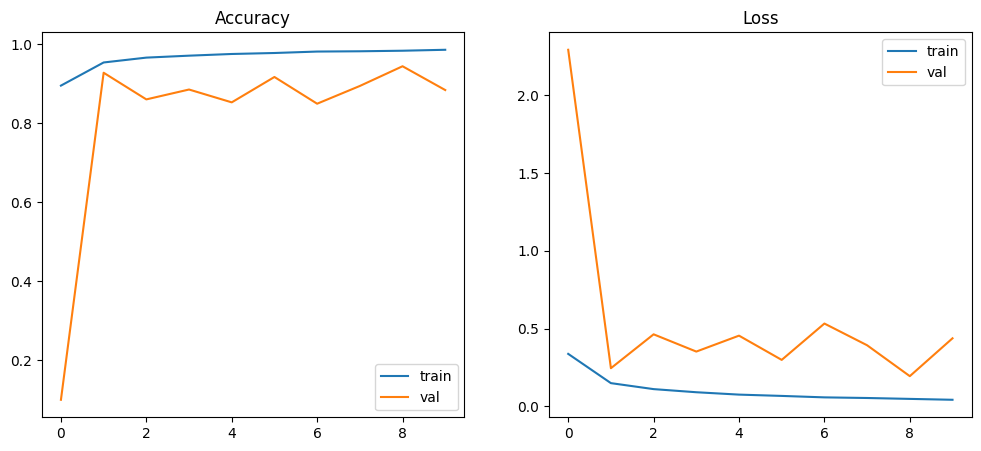

In [42]:
# Training Visualization
plt.figure(figsize=(12,5))

# Accuracy
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='train')
plt.plot(history.history['val_accuracy'], label='val')
plt.title("Accuracy")
plt.legend()

# Loss
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='val')
plt.title("Loss")
plt.legend()

plt.show()

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


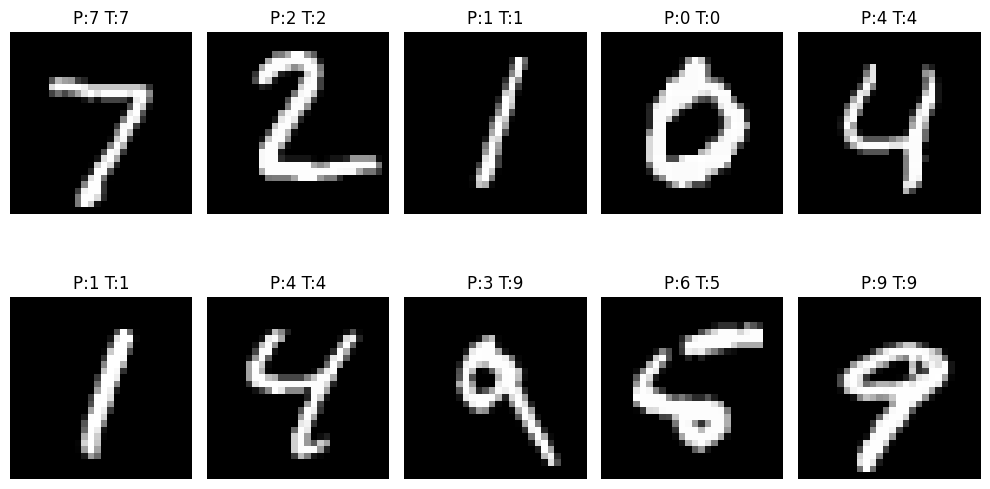

In [43]:
# Prediction Visualization
predictions = model.predict(x_test)

plt.figure(figsize=(10, 6))

for i in range(10):
    plt.subplot(2, 5, i+1)
    plt.imshow(x_test[i].reshape(28,28), cmap='gray')
    pred_label = np.argmax(predictions[i])
    true_label = y_test[i]
    plt.title(f"P:{pred_label} T:{true_label}")
    plt.axis('off')

plt.tight_layout()
plt.show()

# **6. Evaluation**

In [44]:
# Accuracy
test_loss, test_acc = model.evaluate(x_test, y_test)
print("Test Accuracy:", test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8607 - loss: 110.1128
Test Accuracy: 0.8607000112533569


In [36]:
from sklearn.metrics import classification_report

In [45]:
# Classification Report
y_pred_prob = model.predict(x_test)
y_pred = np.argmax(y_pred_prob, axis=1)

print("Classification Report:\n")
print(classification_report(y_test, y_pred))

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Classification Report:

              precision    recall  f1-score   support

           0       0.96      0.99      0.97       980
           1       0.89      1.00      0.94      1135
           2       0.98      0.92      0.95      1032
           3       0.59      0.99      0.74      1010
           4       0.99      0.82      0.90       982
           5       0.82      0.92      0.87       892
           6       0.98      0.95      0.96       958
           7       0.78      0.97      0.87      1028
           8       1.00      0.29      0.45       974
           9       0.98      0.74      0.84      1009

    accuracy                           0.86     10000
   macro avg       0.90      0.86      0.85     10000
weighted avg       0.90      0.86      0.85     10000

